In [1]:
# 第1章｜大盤 1 分 K 爬蟲練習：先執行這一格（這個單元只用 requests 與 pandas，不需要登入 FinLab）
import datetime
import time

import matplotlib.pyplot as plt
import pandas as pd
import requests

# 大盤 1 分 K 爬蟲練習

**對應影片**：第 1 章 單元 3「大盤 1 分 K 爬蟲練習」

**和影片的差異**

| 影片（2018） | 新版教材 |
| --- | --- |
| 網址 `twse.com.tw/exchangeReport/MI_5MINS_INDEX?response=csv`，下載 CSV 再清理 | 證交所改版，改用 `twse.com.tw/rwd/zh/TAIEX/MI_5MINS_INDEX?response=json`，直接拿到 JSON |
| 爬完寫進自建資料庫 | 爬完存成 CSV；需要多年的日資料時，改用 FinLab 資料 API（下一個單元） |

爬蟲的核心步驟和影片一樣：**找網址 → 下載 → 整理成表格 → 存檔**。
證交所「每 5 秒指數統計」提供當天每 5 秒的加權指數，我們把它整理成 1 分 K 與 5 分 K。

## 1. 爬蟲設定

證交所會封鎖短時間大量請求的來源，所以每次請求之間要休息幾秒，並帶上瀏覽器的 User-Agent。

In [2]:
URL = 'https://www.twse.com.tw/rwd/zh/TAIEX/MI_5MINS_INDEX'
HEADERS = {'User-Agent': 'Mozilla/5.0'}
TIMEOUT_SECONDS = 10
REQUEST_INTERVAL_SECONDS = 3
INDEX_FIELD = '發行量加權股價指數'

## 2. 下載某一天的資料

先看證交所回傳的原始內容長什麼樣子：`stat` 是狀態、`fields` 是欄位名稱、`data` 是每 5 秒一列的資料。

In [3]:
def download(date: datetime.date) -> dict:
    """下載某一天的每 5 秒指數，回傳證交所的 JSON。每次下載後休息幾秒，避免被封鎖。"""
    params = {'date': date.strftime('%Y%m%d'), 'response': 'json'}
    try:
        response = requests.get(URL, params=params, headers=HEADERS, timeout=TIMEOUT_SECONDS)
        response.raise_for_status()
        return response.json()
    except requests.RequestException as error:
        raise RuntimeError(
            f'連不上證交所（{error}）。請確認網路正常；若短時間內請求太多次被暫時封鎖，等 10～20 分鐘再試。'
        ) from error
    except ValueError as error:
        raise RuntimeError('證交所回傳的不是 JSON，可能是暫時封鎖或網站維護，請稍後再試。') from error
    finally:
        time.sleep(REQUEST_INTERVAL_SECONDS)


raw = download(datetime.date.today())
{key: raw[key] for key in ('stat', 'date', 'title') if key in raw}

{'stat': 'OK', 'date': '20260924', 'title': '115年09月24日 每5秒指數統計'}

今天如果是假日、或還沒開盤，`stat` 會是「沒有符合條件的資料」。
所以我們寫一個函式，從今天往前找，找到最近一個有資料的交易日。

In [4]:
MAX_LOOKBACK_DAYS = 14


def is_trading_day(raw: dict) -> bool:
    return raw.get('stat') == 'OK' and bool(raw.get('data'))


def latest_trading_day(start: datetime.date) -> tuple[datetime.date, dict]:
    """從 start 往前找最近一個有資料的交易日。"""
    for days_ago in range(MAX_LOOKBACK_DAYS):
        date = start - datetime.timedelta(days=days_ago)
        raw = download(date)
        if is_trading_day(raw):
            return date, raw
    raise RuntimeError(f'往前 {MAX_LOOKBACK_DAYS} 天都沒有資料，證交所可能在維護，請稍後再試。')


date, raw = latest_trading_day(datetime.date.today())
print('最近的交易日：', date)
print('欄位：', raw['fields'][:4], '...')
raw['data'][:3]

最近的交易日： 2026-09-24
欄位： ['時間', '發行量加權股價指數', '未含金融保險股指數', '未含電子股指數'] ...


[['09:00:00',
  '48,157.29',
  '42,970.41',
  '25,804.79',
  '16,459.75',
  '126.23',
  '1,902.19',
  '376.73',
  '461.25',
  '543.68',
  '106.39',
  '163.31',
  '192.23',
  '91.95',
  '136.92',
  '274.00',
  '119.48',
  '190.74',
  '292.35',
  '3,066.77',
  '1,641.90',
  '463.74',
  '74.54',
  '234.57',
  '950.90',
  '369.18',
  '238.39',
  '285.87',
  '447.65',
  '212.40',
  '101.60',
  '3,593.69',
  '236.43',
  '116.27',
  '131.67',
  '40.09',
  '56.10',
  '100.14',
  '274.05'],
 ['09:00:05',
  '48,075.39',
  '42,898.88',
  '25,760.76',
  '16,436.76',
  '126.09',
  '1,901.95',
  '373.97',
  '461.05',
  '543.70',
  '106.39',
  '163.48',
  '191.85',
  '92.16',
  '137.10',
  '274.00',
  '119.50',
  '190.60',
  '291.94',
  '3,061.56',
  '1,639.62',
  '463.77',
  '74.35',
  '234.53',
  '948.38',
  '368.45',
  '238.65',
  '284.05',
  '447.24',
  '212.31',
  '101.63',
  '3,586.18',
  '236.48',
  '116.27',
  '131.65',
  '40.09',
  '55.93',
  '100.14',
  '273.93'],
 ['09:00:10',
  '47,904.05

## 3. 整理成表格

1. 用 `fields` 當欄位名稱建立 DataFrame。
2. 把「日期 + 時間」變成 index。
3. 數字裡有千分位逗號（`47,800.17`），去掉逗號才能轉成數字。

In [5]:
def to_ticks(date: datetime.date, raw: dict) -> pd.Series:
    """把證交所 JSON 整理成以時間為 index 的加權指數 Series。"""
    table = pd.DataFrame(raw['data'], columns=raw['fields'])
    table.index = pd.to_datetime(f'{date} ' + table['時間'])
    return table[INDEX_FIELD].str.replace(',', '').astype(float).rename('taiex')


ticks = to_ticks(date, raw)
ticks.head()

時間
2026-09-24 09:00:00    48157.29
2026-09-24 09:00:05    48075.39
2026-09-24 09:00:10    47904.05
2026-09-24 09:00:15    47832.48
2026-09-24 09:00:20    47824.33
Name: taiex, dtype: float64

## 4. 從每 5 秒資料做出 1 分 K、5 分 K

`resample('1min').ohlc()` 會把每一分鐘內的資料整理成開、高、低、收四個價格，也就是 K 棒。

In [6]:
kbar_1min = ticks.resample('1min').ohlc().dropna()
kbar_5min = ticks.resample('5min').ohlc().dropna()
kbar_1min.head()

,open,high,low,close
時間,,,,
2026-09-24 09:00:00,48157.29,48157.29,47784.80,47853.97
2026-09-24 09:01:00,47851.99,47957.65,47833.18,47957.65
2026-09-24 09:02:00,47911.96,47963.96,47908.42,47940.42
2026-09-24 09:03:00,47939.55,47947.78,47875.38,47937.85
2026-09-24 09:04:00,47944.10,47945.26,47895.00,47945.26


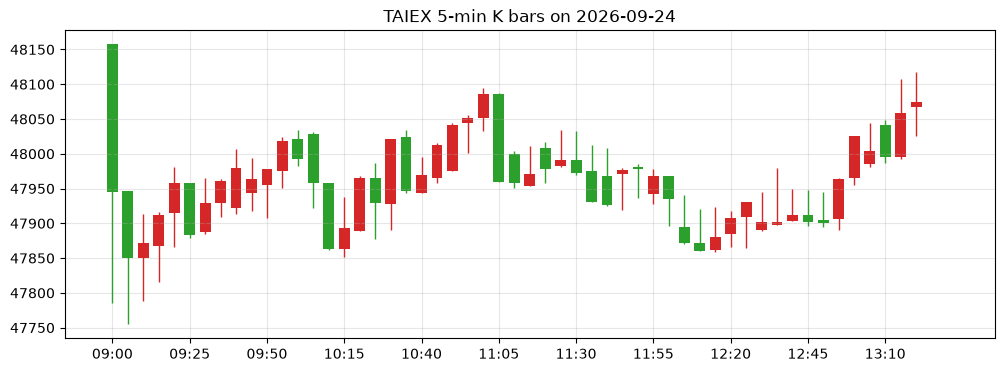

In [7]:
def plot_candles(kbar: pd.DataFrame, title: str) -> None:
    """用 matplotlib 畫 K 線：紅 K 代表收盤高於開盤，綠 K 代表收盤低於開盤。"""
    rising = kbar['close'] >= kbar['open']
    colors = rising.map({True: 'tab:red', False: 'tab:green'})
    x = range(len(kbar))
    body_bottom = kbar[['open', 'close']].min(axis=1)
    body_height = (kbar['close'] - kbar['open']).abs()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.vlines(x, kbar['low'], kbar['high'], colors=colors, linewidth=1)
    ax.bar(x, body_height, bottom=body_bottom, color=colors, width=0.7)
    tick_step = max(len(kbar) // 10, 1)
    ax.set_xticks(list(x)[::tick_step], kbar.index.strftime('%H:%M')[::tick_step])
    ax.set_title(title)
    ax.grid(alpha=0.3)


plot_candles(kbar_5min, f'TAIEX 5-min K bars on {date}')

## 5. 一次抓多天、存成 CSV

把前面的函式組合起來，往前抓幾個交易日。`download` 每次下載後都會休息幾秒，可以降低抓多天時被證交所封鎖的機會。

In [8]:
N_TRADING_DAYS = 3


def crawl_recent(n_days: int, start: datetime.date) -> pd.DataFrame:
    """抓最近 n_days 個交易日的 1 分 K。"""
    kbars = []
    date = start
    while len(kbars) < n_days:
        date, raw = latest_trading_day(date)
        kbars.append(to_ticks(date, raw).resample('1min').ohlc().dropna())
        date -= datetime.timedelta(days=1)
    return pd.concat(kbars).sort_index()


history = crawl_recent(N_TRADING_DAYS, datetime.date.today())
history.to_csv('taiex_1min.csv')
print(f'共 {len(history)} 根 1 分 K，已存成 taiex_1min.csv')
history.groupby(history.index.date).agg(open=('open', 'first'), close=('close', 'last'), bars=('close', 'size'))

共 813 根 1 分 K，已存成 taiex_1min.csv


,open,close,bars
2026-09-22,47718.84,47800.17,271
2026-09-23,47800.17,48157.29,271
2026-09-24,48157.29,48024.60,271


## 下一步

爬蟲很適合抓「少量、即時」的資料。但如果要做多年的回測，一天一天爬又慢又容易被封鎖。
下一個單元改用 FinLab 資料 API，一行取得上市櫃所有股票十多年的資料。